# 02 Single-market deep dive

Apply the Bayesian-inverse-problem framework to one resolved
Polymarket binary market. We pull the live price-volume history and
work entirely in the **raw Yes/No frame**: `Y = 1` means the market
resolved Yes, `Y = 0` means it resolved No. (We deliberately do *not*
use the winner-alignment convention `Y = 1 \equiv \text{winner}` so
that everything plays well with the empirical-Bayes asymmetric volume
prior in section 1c.) We then run the full diagnostic suite from
Section 4 of the paper:

1. **Online posterior trace** `pi_t = P(Y=Yes \mid H_t)` overlaid on
   the market-implied `P(Yes)`.
2. **Posterior concentration** by re-evaluating SMC at sub-horizons.
3. **Stability** under Gaussian perturbations of `Delta x` against the
   Theorem 4.4 bound.
4. **Information gain dynamics** `IG(H_t)` plus effective
   informativeness `eta(v_t; theta_hat)`.

In [1]:
from __future__ import annotations
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pml_market import data, diagnostics
from pml_market import (
    InverseProblem, 
    BaseModel, BasePrior,
    GaussianVolModel, GaussianVolPrior,
    SMCInference, VIInference,
)

# Single inverse problem reused throughout this notebook.
problem = InverseProblem(BaseModel(), BasePrior())

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

/Users/fgao23/miniconda3/envs/datasc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pick a market

We auto-discover resolved binary markets from the Gamma API, filter to
those with enough trades and volume, and pick one **uniformly at
random** using `RANDOM_SEED`. Change `RANDOM_SEED` to get a different
draw. Set `OVERRIDE_SLUG` to pin a specific market instead.

In [11]:
OVERRIDE_SLUG: str | None = None  # set to a slug string to pin a specific market
RANDOM_SEED    = 42# change to get a different random draw
BUCKET_MINUTES = 60
MIN_TRADES     = 200
MIN_VOLUME     = 50_000.0
OVERRIDE_SLUG = "fisa-section-702-reauthorized-before-it-expires"
# OVERRIDE_SLUG = "will-trump-endorse-an-israeli-ceasefire-in-lebanon-by-april-30"
# Filter to markets where a specific label won ('Yes', 'No', or None for any).
# We DO NOT winner-align in this notebook, so y comes from the raw Yes/No
# label: y = 1 if the market resolved Yes, y = 0 if it resolved No.
WINNER_LABEL_FILTER: str | None = None
# Keep only the last LOOKBACK_BUCKETS before resolution (None = full history).
# Useful for long-running markets where early history is noise; the model sees
# only the window ending at resolution.
LOOKBACK_BUCKETS: int | None = None  # e.g. 288 = last 24 h at 5-min buckets
if OVERRIDE_SLUG is not None:
    traj = data.fetch_market_history(OVERRIDE_SLUG, bucket_minutes=BUCKET_MINUTES)
else:
    candidates = data.list_resolved_binary_markets(limit=50, min_volume=MIN_VOLUME)
    print(f'fetched {len(candidates)} resolved binary markets, filtering...')

    valid = []
    for m in candidates:
        try:
            t = data._trajectory_from_market(m, bucket_minutes=BUCKET_MINUTES)
        except Exception:
            continue
        if t['metadata']['trade_count'] < MIN_TRADES:
            continue
        if WINNER_LABEL_FILTER is not None:
            if t['winner_label'].lower() != WINNER_LABEL_FILTER.lower():
                continue
        valid.append(t)

    if not valid:
        raise RuntimeError('no resolved binary with enough trades found '
                           f'(WINNER_LABEL_FILTER={WINNER_LABEL_FILTER!r})')

    rng_pick = np.random.default_rng(RANDOM_SEED)
    pick_idx = int(rng_pick.integers(len(valid)))
    traj = valid[pick_idx]
    print(f'found {len(valid)} valid markets'
          + (f' where winner={WINNER_LABEL_FILTER!r}' if WINNER_LABEL_FILTER else '')
          + f', randomly picked index {pick_idx} (RANDOM_SEED={RANDOM_SEED})')

# Trim to last LOOKBACK_BUCKETS before resolution (full history if None).
full_T = traj['horizon']
if LOOKBACK_BUCKETS is not None:
    traj = data.truncate_trajectory(traj, LOOKBACK_BUCKETS)
    print(f'truncated: full T={full_T} → using last T={traj["horizon"]} buckets '
          f'({traj["horizon"] * BUCKET_MINUTES / 60:.1f} h before resolution)')

SELECTED_SLUG = traj['metadata']['slug']
print(f'\nslug:         {SELECTED_SLUG!r}')
print(f'horizon T:    {traj["horizon"]} buckets  ({traj["horizon"] * BUCKET_MINUTES / 60:.1f} h)')
print(f'winner_label: {traj["winner_label"]!r}  '
      f'(=> raw outcome y = {1 if traj["winner_label"] == "Yes" else 0})')


slug:         'fisa-section-702-reauthorized-before-it-expires'
horizon T:    522 buckets  (522.0 h)
winner_label: 'Yes'  (=> raw outcome y = 1)


In [12]:
dx, v, y = data.trajectory_to_arrays_raw(traj)
T = dx.shape[0]

# Build the un-aligned price sequence P(Yes_t) once; downstream cells reuse it.
# trajectory_to_arrays_raw returns dx = increments of logit(P(Yes)), and
# leaves volume invariant.
prices_yes = np.asarray(traj['prices'], dtype=np.float64)
if traj['winner_label'] == 'No':
    prices_yes = 1.0 - prices_yes
times = np.array(traj['times']) / 3600.0  # hours since first bucket
times -= times[0]

print(f'Polymarket outcome that won: {traj["winner_label"]!r}')
print(f'winner_index in outcomes list: {traj["winner_index"]}  '
      f'(outcomes = {traj["metadata"]["outcomes"]})')
print(f'y (raw Yes/No convention):   {y}   '
      f'(1 if Yes resolved, 0 if No resolved)')
print()
print(f'T = {T} buckets  ({T * BUCKET_MINUTES / 60:.1f} h)')
print(f'|dx| mean={np.mean(np.abs(dx)):.4f}  0.99-qtile={np.quantile(np.abs(dx), 0.99):.4f}')
print(f'v    mean={v.mean():.2f}  max={v.max():.2f}  zero={( v == 0).mean():.2%}')

Polymarket outcome that won: 'Yes'
winner_index in outcomes list: 0  (outcomes = ['Yes', 'No'])
y (raw Yes/No convention):   1   (1 if Yes resolved, 0 if No resolved)

T = 522 buckets  (522.0 h)
|dx| mean=0.1191  0.99-qtile=1.2021
v    mean=194.93  max=17533.14  zero=64.56%


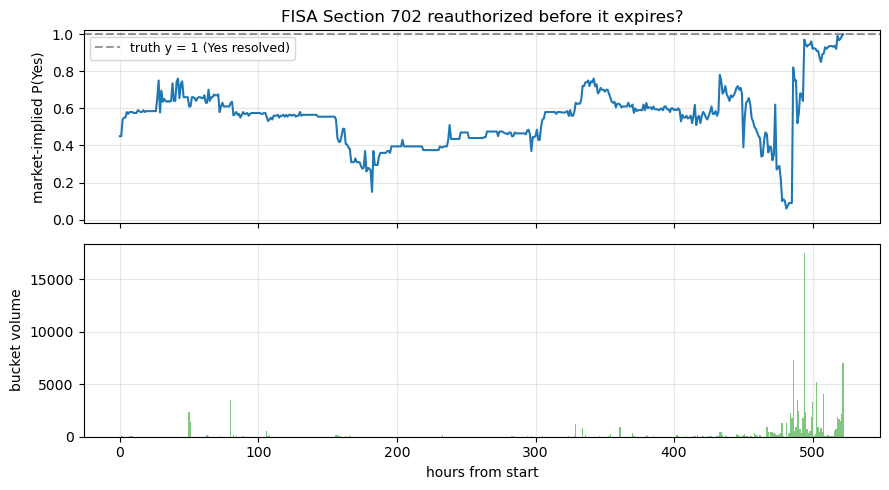

In [13]:
# Plot the raw (un-aligned) market history: P(Yes) + bucket volume.
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
axes[0].plot(times, prices_yes, color='C0')
axes[0].axhline(float(y), color='k', linestyle='--', alpha=0.4,
                label=f'truth y = {y} ({traj["winner_label"]} resolved)')
axes[0].set_ylabel('market-implied P(Yes)')
axes[0].set_ylim(-0.02, 1.02)
axes[0].legend(loc='best', fontsize=9)
axes[0].set_title(f'{traj["metadata"]["question"]}')
axes[1].bar(times[1:], v, width=BUCKET_MINUTES / 60.0, color='C2', alpha=0.6)
axes[1].set_ylabel('bucket volume')
axes[1].set_xlabel('hours from start')
plt.tight_layout()
plt.show()

## (1) Online posterior trace: Compare base with Volume Model

Run SMC under both outcomes with `record_pi_t=True` so we get
`pi_t = P(Y=Yes | H_t)` after every step. Compare to the market-implied
`P(Yes)`. Both should converge to the truth `y` (=1 if Yes resolved,
=0 if No resolved).

In [19]:
n_particles = 1600
smc_engine = SMCInference(n_particles=n_particles, mcmc_steps=4)
smc_res = problem.infer(dx, v, smc_engine, pi0=0.5, seed=42, record_pi_t=True)
sign_truth = 2 * y - 1   # +1 if Yes resolved, -1 if No resolved
print(f'SMC log BF (Yes vs No)            = {smc_res["log_BF"]:+.3f}')
print(f'SMC log BF in favor of truth (y={y}) = {sign_truth * smc_res["log_BF"]:+.3f}')
print(f'SMC posterior P(Y=Yes | H_T)      = {smc_res["posterior"]:.4f}  (truth y = {y})')
print(f'SMC posterior P(truth | H_T)      = '
      f'{smc_res["posterior"] if y == 1 else 1 - smc_res["posterior"]:.4f}')

SMC log BF (Yes vs No)            = -51.435
SMC log BF in favor of truth (y=1) = -51.435
SMC posterior P(Y=Yes | H_T)      = 0.0000  (truth y = 1)
SMC posterior P(truth | H_T)      = 0.0000


In [27]:
from joblib import Parallel, delayed
import numpy as np

def run_base_seed(seed, dx, v, n_particles=1600, mcmc_steps=4):
    # Build objects inside each worker to avoid cross-process state issues
    from pml_market import InverseProblem, BaseModel, BasePrior, SMCInference

    problem_local = InverseProblem(BaseModel(), BasePrior())
    res = problem_local.infer(
        dx, v,
        SMCInference(n_particles=n_particles, mcmc_steps=mcmc_steps),
        pi0=0.5,
        seed=int(seed),
        record_pi_t=False,
    )
    return int(seed), float(res["log_BF"]), float(res["posterior"])

seed_grid = np.arange(20)

results = Parallel(
    n_jobs=-1,         # use all CPU cores
    backend="loky",    # process-based
    verbose=10
)(
    delayed(run_base_seed)(s, dx, v, n_particles=n_particles, mcmc_steps=4)
    for s in seed_grid
)

# Unpack
seeds, base_log_bf, base_post = map(np.array, zip(*results))

print(f"Ran {len(seeds)} seeds")
print(f"log BF mean={base_log_bf.mean():+.3f}, std={base_log_bf.std(ddof=1):.3f}")
print(f"posterior mean={base_post.mean():.4f}, std={base_post.std(ddof=1):.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.


done
done


[Parallel(n_jobs=-1)]: Done   2 out of  20 | elapsed:   55.7s remaining:  8.4min


done
done
done


[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:  1.0min remaining:  3.1min


...

[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed:  1.7min remaining:   44.7s


done
done
done
done


[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:  1.8min remaining:   19.1s


done
done
Ran 20 seeds
log BF mean=+9.923, std=21.047
posterior mean=0.6466, std=0.4691


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:  1.9min finished


BASE model seed sensitivity
  runs                    = 20
  mean log BF             = +9.923
  std  log BF             = 21.047
  median log BF           = +8.424
  IQR log BF              = [-7.305, +26.042]
  10-90% log BF           = [-12.048, +32.779]
  sign agreement fraction = 65.0%
  BF spread vs median     = x0.000 to x7689314893083.087


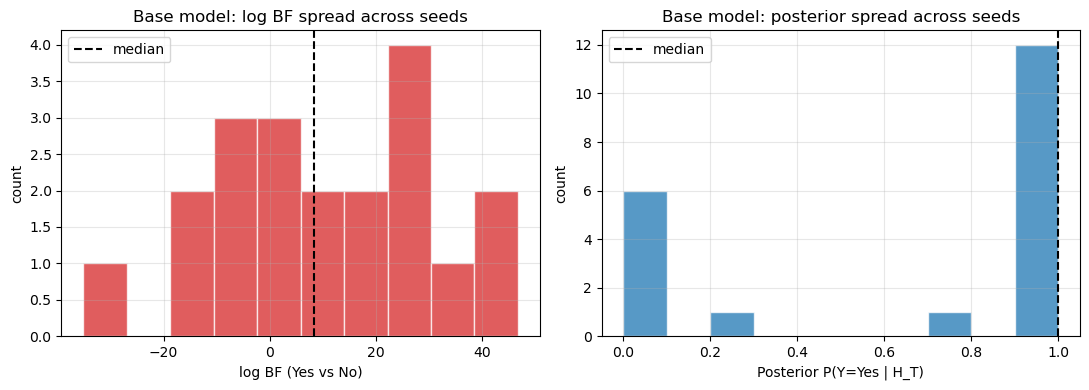

In [28]:
# Summary stats for factor spread.
q_log = np.quantile(base_log_bf, [0.10, 0.25, 0.50, 0.75, 0.90])
sign_agree = max((base_log_bf > 0).mean(), (base_log_bf < 0).mean())

print('BASE model seed sensitivity')
print(f'  runs                    = {len(seed_grid)}')
print(f'  mean log BF             = {base_log_bf.mean():+.3f}')
print(f'  std  log BF             = {base_log_bf.std(ddof=1):.3f}')
print(f'  median log BF           = {q_log[2]:+.3f}')
print(f'  IQR log BF              = [{q_log[1]:+.3f}, {q_log[3]:+.3f}]')
print(f'  10-90% log BF           = [{q_log[0]:+.3f}, {q_log[4]:+.3f}]')
print(f'  sign agreement fraction = {sign_agree:.1%}')

# Convert to relative BF scale around the median to avoid overflow.
rel_bf = np.exp(np.clip(base_log_bf - q_log[2], -50, 50))
print(f'  BF spread vs median     = x{np.quantile(rel_bf, 0.10):.3f} to x{np.quantile(rel_bf, 0.90):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(base_log_bf, bins=10, color='C3', alpha=0.75, edgecolor='white')
axes[0].axvline(q_log[2], color='k', linestyle='--', label='median')
axes[0].set_xlabel('log BF (Yes vs No)')
axes[0].set_ylabel('count')
axes[0].set_title('Base model: log BF spread across seeds')
axes[0].legend()

axes[1].hist(base_post, bins=10, color='C0', alpha=0.75, edgecolor='white')
axes[1].axvline(np.median(base_post), color='k', linestyle='--', label='median')
axes[1].set_xlabel('Posterior P(Y=Yes | H_T)')
axes[1].set_ylabel('count')
axes[1].set_title('Base model: posterior spread across seeds')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Run the volume-aware model from models/ + priors/ modules directly.
problem_vol = InverseProblem(GaussianVolModel(), GaussianVolPrior())
smc_engine_vol = SMCInference(n_particles=n_particles, mcmc_steps=4)
smc_res_vol = problem_vol.infer(dx, v, smc_engine_vol, pi0=0.5, seed=42, record_pi_t=True)

print(f'Volume model log BF (Yes vs No)            = {smc_res_vol["log_BF"]:+.3f}')
print(f'Volume model log BF in favor of truth (y={y}) = {sign_truth * smc_res_vol["log_BF"]:+.3f}')
print(f'Volume model posterior P(Y=Yes | H_T)      = {smc_res_vol["posterior"]:.4f}  (truth y = {y})')
print(f'Volume model posterior P(truth | H_T)      = '
      f'{smc_res_vol["posterior"] if y == 1 else 1 - smc_res_vol["posterior"]:.4f}')

Volume model log BF (Yes vs No)            = +5.775
Volume model log BF in favor of truth (y=1) = +5.775
Volume model posterior P(Y=Yes | H_T)      = 0.9969  (truth y = 1)
Volume model posterior P(truth | H_T)      = 0.9969


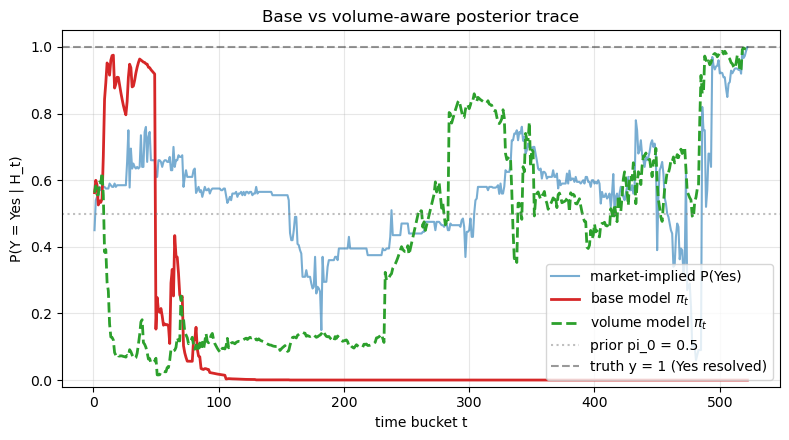

In [22]:
# Overlay base-model and volume-model posterior traces.
ts = np.arange(1, T + 1)
fig, ax = plt.subplots()
ax.plot(ts, prices_yes[1:], color='C0', alpha=0.6, label='market-implied P(Yes)')
ax.plot(ts, smc_res['pi_t'], color='C3', linestyle='-', linewidth=2,
        label=r'base model $\pi_t$')
ax.plot(ts, smc_res_vol['pi_t'], color='C2', linestyle='--', linewidth=2,
        label=r'volume model $\pi_t$')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='prior pi_0 = 0.5')
ax.axhline(float(y), color='k', linestyle='--', alpha=0.4,
           label=f'truth y = {y} ({traj["winner_label"]} resolved)')
ax.set_xlabel('time bucket t')
ax.set_ylabel('P(Y = Yes | H_t)')
ax.set_title('Base vs volume-aware posterior trace')
ax.set_ylim(-0.02, 1.05)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## (2) Posterior concentration vs sub-horizon

Truncate the history to `T_sub` and re-run SMC for each sub-horizon.
We expect the error `1 - pi_T` to decay roughly exponentially in `T`
once the KL-projection gap is identified (Theorem 4.3).

In [ ]:
sub_grid = sorted(set([max(5, T // 10), max(10, T // 5),
                       max(20, T // 3), max(40, T // 2),
                       max(80, T * 3 // 4), T]))
sub_grid = [t for t in sub_grid if t <= T]
errs = []
sub_engine = SMCInference(n_particles=n_particles, mcmc_steps=3)
for Tsub in tqdm(sub_grid, desc='sub-horizons'):
    r = problem.infer(dx[:Tsub], v[:Tsub], sub_engine, pi0=0.5, seed=1)
    # Error = |pi_T - y| in the raw Yes/No frame (works for y in {0, 1}).
    errs.append(abs(r['posterior'] - y))
    print(f'  T_sub={Tsub:>4d}: posterior={r["posterior"]:.4f}  '
          f'|pi_T - y|={errs[-1]:.4f}')
errs = np.array(errs)

In [ ]:
fig, ax = plt.subplots()
ax.plot(sub_grid, np.clip(errs, 1e-6, None), 'o-')
ax.set_yscale('log')
ax.set_xlabel('T (sub-horizon)')
ax.set_ylabel(f'|pi_T - y|  (log scale, y = {y})')
ax.set_title('(2) Posterior concentration vs sub-horizon')
plt.tight_layout()
plt.show()

## (3) Stability to increment perturbations

Add iid Gaussian noise to `Delta x` for several `sigma`, re-run SMC,
and compare `|log BF(h) - log BF(h')|` to the Theorem 4.4 bound with
`Lx = R / sigma_min^2` and `R = 0.99` quantile of `|Delta x|`.

In [ ]:
# Use *common random numbers* across base and perturbed: fix the SMC
# seed so that noise from particle randomness cancels and we measure
# only the effect of the perturbation.
sigmas = [0.005, 0.01, 0.02, 0.05, 0.1]
n_trials = 10
# R from full history is fine here: it parameterizes the theoretical bound,
# not the inference itself.
R = float(np.quantile(np.abs(dx), 0.99))
Lx = diagnostics.gaussian_lipschitz_constant(R, sigma_min=0.2)
# Common-random-numbers seed: same SMC randomness for base and perturbed so
# particle noise cancels and we isolate the perturbation effect.
crn_seed = 7777
pert_engine = SMCInference(n_particles=600, mcmc_steps=3)
log_BF_base = problem.infer(dx, v, pert_engine, pi0=0.5, seed=crn_seed)['log_BF']
diffs = []
for s_idx, s in enumerate(sigmas):
    tr = []
    for trial in range(n_trials):
        # Deterministic per-(sigma, trial) seed: perturbations are independent
        # across sigma levels and trials (no shared rng state).
        rng_t = np.random.default_rng(500 + s_idx * 100 + trial)
        dxp = diagnostics.perturb_history(dx, s, rng=rng_t)
        rp = problem.infer(dxp, v, pert_engine, pi0=0.5, seed=crn_seed)
        tr.append(abs(rp['log_BF'] - log_BF_base))
    diffs.append(np.mean(tr))
    print(f'  sigma={s:>5.3f}  mean |delta log BF|={diffs[-1]:.3f}')
diffs = np.array(diffs)
bounds = 2 * Lx * T * np.array(sigmas) * np.sqrt(2 / np.pi)

In [ ]:
fig, ax = plt.subplots()
ax.plot(sigmas, diffs, 'o-', label="|log BF(h) - log BF(h')|")
ax.plot(sigmas, bounds, '--', label='Theorem 4.4 bound')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('perturbation std sigma')
ax.set_ylabel('|delta log BF|')
ax.set_title('(3) Stability under perturbation')
ax.legend()
plt.tight_layout()
plt.show()

## (4) Information gain and effective informativeness

Plot realized IG(H_t) over time; saturating values indicate the
posterior has concentrated. The effective informativeness `eta(v;theta)`
(Definition 4.3) is computed at the variational-mean theta from VI.

In [ ]:
ig = diagnostics.information_gain_trace(smc_res['pi_t'], pi0=0.5)

# Use VI to get a single theta point estimate (variational mean) for
# eta(v; theta_hat).  We want the theta posterior conditioned on the truth
# y, so pick vi0 if No resolved (y=0) and vi1 if Yes resolved (y=1).
vi_engine = VIInference(n_steps=1200, n_samples=8, learning_rate=0.05)
vi_res = problem.infer(dx, v, vi_engine, pi0=0.5, seed=0)
theta_hat = vi_res[f'vi{y}']['theta_mean']
eta = diagnostics.effective_informativeness(v, theta_hat)
print(f'VI log BF = {vi_res["log_BF"]:+.3f}  (SMC: {smc_res["log_BF"]:+.3f})')
print(f'theta_hat from vi{y} (conditioned on truth Y={y})')
print(f'theta_hat omega = {theta_hat["omega"]}')
print(f'theta_hat mu1   = {float(theta_hat["mu1"]):.3f}')
print(f'theta_hat mu3   = {float(theta_hat["mu3"]):.3f}')
print(f'theta_hat tau3  = {float(theta_hat["tau3"]):.3f}')

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
axes[0].plot(ts, ig, color='C3', label='IG(H_t)')
axes[0].axhline(np.log(2), linestyle='--', color='red', label='log 2 (prior entropy)')
axes[0].set_ylabel('IG (nats)')
axes[0].set_title('(4) Information gain and effective informativeness')
axes[0].legend()

axes[1].plot(ts, eta, color='C2', label='eta(v_t; theta_hat)')
axes[1].axhline(0.0, linestyle=':', color='gray')
axes[1].set_xlabel('time bucket t')
axes[1].set_ylabel('eta')
axes[1].legend()
plt.tight_layout()
plt.show()